<a href="https://colab.research.google.com/github/Yanina2105/MD-Lab08_FT/blob/develop/SEMANA_8_%C3%81RBOLES_DE_DECISI%C3%93N_BOSQUES_ALEATORIOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SEMANA 8: ÁRBOLES DE DECISIÓN. BOSQUES ALEATORIOS**

Con base a datos de cáncer de mama alojados en el repositorio UCI Machine Learning Repository
(https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+%28original%29) y utilizando
las librerías de Python que se indican,

In [1]:
import pandas as pd
import numpy as np

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data'
columnas = ['Sample_code_number', 'Clump_thickness', 'Uniformity_of_cell_size', 'Uniformity_of_cell_shape', 'Marginal_adhesion',
            'Single_epithelial_cell_size', 'Bare_nuclei', 'Bland_chromatin', 'Normal_nucleoli', 'Mitoses', 'Class']
df = pd.read_csv(url, names=columnas)
df.head()

,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


## **a. Lea la base de datos, realice imputaciones, tratamiento de outliers, transformaciones de datos y desbalance de clases en caso sea necesario. Además, separe la variable de clasificación del resto de variables para luego obtener los datos de entrenamiento y prueba, tomando de este último el 25% de datos.**

In [3]:
# Cambio de categorías para la variable 'Class': 2 o 4 por 0 o 1
df['Class'] = np.where(df['Class'] == 2, 0, df['Class'])
df['Class'] = np.where(df['Class'] == 4, 1, df['Class'])

In [4]:
# Tipo de datos
df.dtypes

,0
Sample_code_number,int64
Clump_thickness,int64
Uniformity_of_cell_size,int64
Uniformity_of_cell_shape,int64
Marginal_adhesion,int64
Single_epithelial_cell_size,int64
Bare_nuclei,object
Bland_chromatin,int64
Normal_nucleoli,int64
Mitoses,int64


In [5]:
# Limpieza de datos
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
df['Bare_nuclei'] = df['Bare_nuclei'].astype(int)
df.drop(columns=['Sample_code_number'], inplace=True)

In [6]:
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
Clump_thickness                0
Uniformity_of_cell_size        0
Uniformity_of_cell_shape       0
Marginal_adhesion              0
Single_epithelial_cell_size    0
Bare_nuclei                    0
Bland_chromatin                0
Normal_nucleoli                0
Mitoses                        0
Class                          0
dtype: int64


In [7]:
for columna in df.columns[:-1]:
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

Outliers = df[(df[columna] >= Q1 - 1.5 * IQR) & (df[columna] <= Q3 + 1.5 * IQR)]
Outliers

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...
692,3,1,1,1,2,1,1,1,1,0
694,3,1,1,1,3,2,1,1,1,0
695,2,1,1,1,2,1,1,1,1,0
697,4,8,6,4,3,4,10,6,1,1


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X = df.drop('Class', axis=1)
y = df['Class']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## **b. Genere el modelo de árbol de decisión para clasificación y la profundidad adecuada para este. Además, calcule las métricas de clasificación e interprete sus resultados más importantes.**

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [12]:
# Crear el modelo de arborl de decisión
ad_model = DecisionTreeClassifier(random_state=42)

In [13]:
# Ajustar el modelo
ad_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [14]:
# Predecir con los datos de prueba
y_pred_ad = ad_model.predict(X_test)

In [15]:
# Evaluación del modelo
print("Árbol de Decisión - Métricas de Clasificación:")
print(classification_report(y_test, y_pred_ad))

Árbol de Decisión - Métricas de Clasificación:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       103
           1       0.97      0.88      0.92        68

    accuracy                           0.94       171
   macro avg       0.95      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



In [46]:
ad_model = DecisionTreeClassifier(max_depth=3, random_state=42)
ad_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

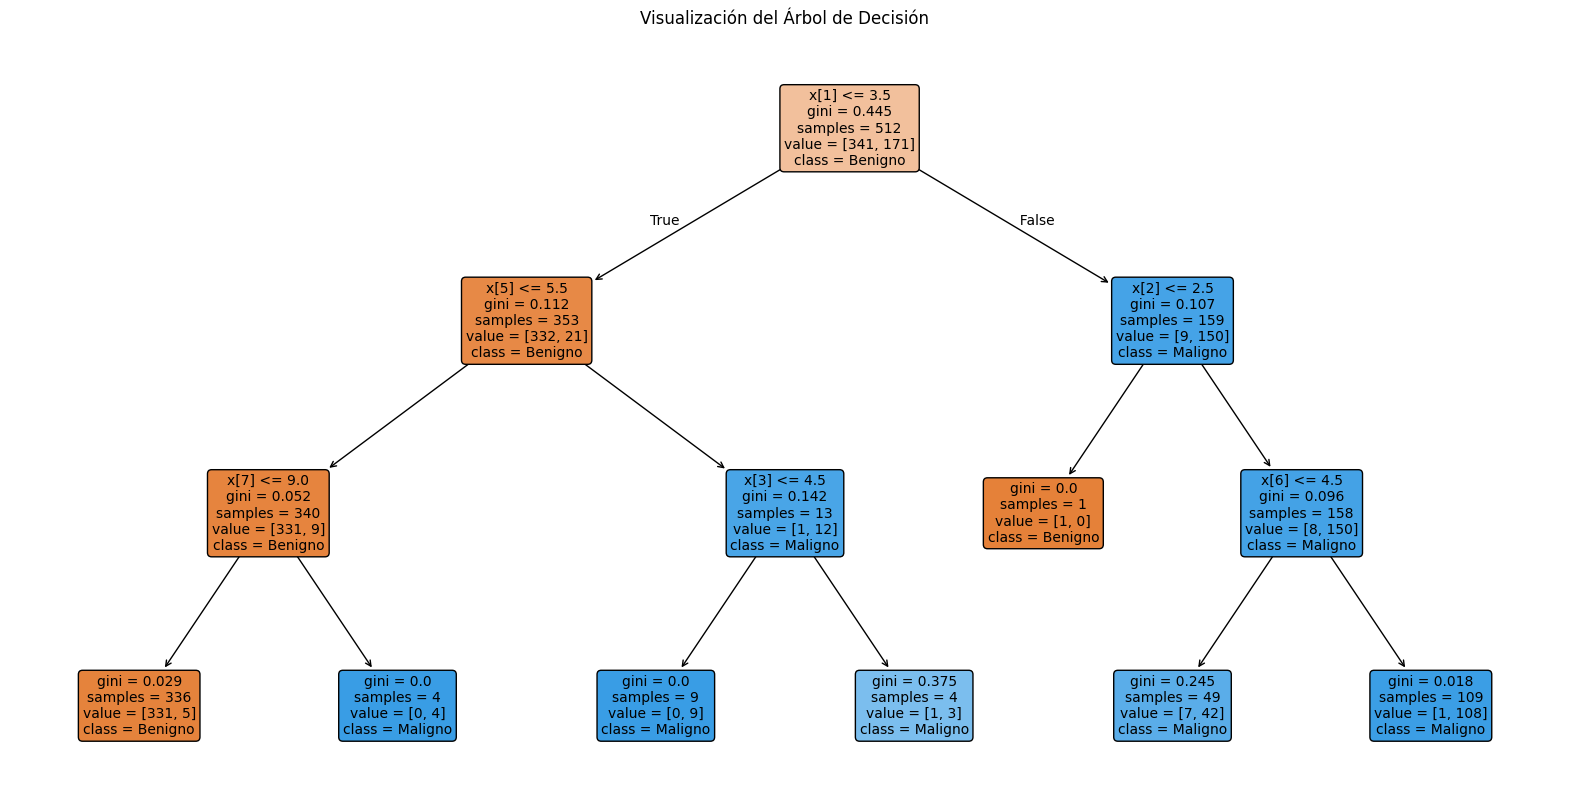

In [47]:
# Visualizar el árbol de decisión completo
plt.figure(figsize=(20, 10))
plot_tree(ad_model,
          filled=True,
          class_names=['Benigno', 'Maligno'],
          rounded=True,
          fontsize=10)
plt.title("Visualización del Árbol de Decisión")
plt.show()

In [37]:
matriz_confusion_ad = confusion_matrix(y_test, y_pred_ad)

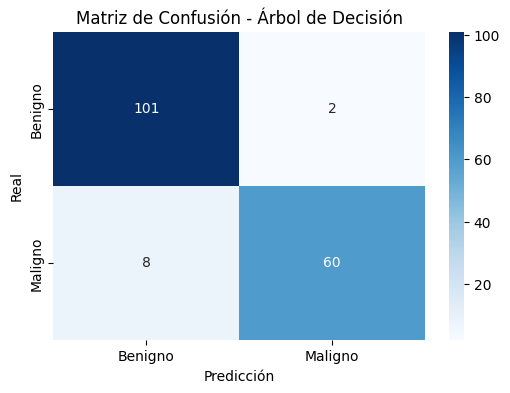

In [38]:
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_confusion_ad, annot=True, fmt='d', cmap='Blues', xticklabels=['Benigno', 'Maligno'], yticklabels=['Benigno', 'Maligno'])
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

## **c. Genere el modelo de bosques aleatorios para clasificación. Además, calcule las métricas de clasificación y compárelas con las del árbol de clasificación. ¿Hubo mejoras o no?**

In [16]:
from sklearn.ensemble import RandomForestClassifier

In [17]:
# Crear el modelo de bosque aleatorio
ba_model = RandomForestClassifier(random_state=42)

In [18]:
# Ajustar el modelo
ba_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
# Predecir con los datos de prueba
y_pred_ba = ba_model.predict(X_test)

In [20]:
# Evaluación del modelo
print("Bosques Aleatorios - Métricas de Clasificación:")
print(classification_report(y_test, y_pred_ba))

Bosques Aleatorios - Métricas de Clasificación:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       103
           1       0.98      0.88      0.93        68

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



In [39]:
# Matriz de confusión para Bosques Aleatorios
matriz_confusion_ba = confusion_matrix(y_test, y_pred_ba)

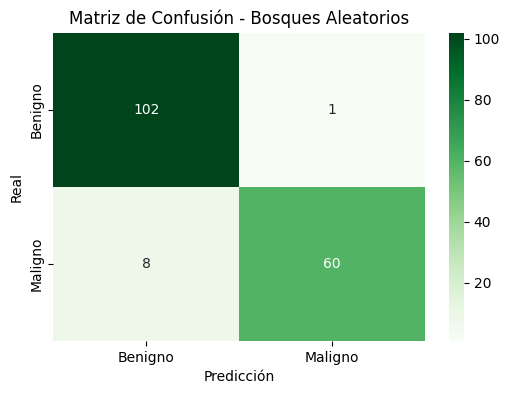

In [40]:
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_confusion_ba, annot=True, fmt='d', cmap='Greens', xticklabels=['Benigno', 'Maligno'], yticklabels=['Benigno', 'Maligno'])
plt.title('Matriz de Confusión - Bosques Aleatorios')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

### **Metricas de arbol de decisión y bosque aletorio**

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
# Métricas de ambos modelos
print("Exactitud Árbol de Decisión:", accuracy_score(y_test, y_pred_ad))
print("Exactitud Bosques Aleatorios:", accuracy_score(y_test, y_pred_ba))

Exactitud Árbol de Decisión: 0.9415204678362573
Exactitud Bosques Aleatorios: 0.9473684210526315


### **Conclusión: El arbol de decisión tiene una precisión de 94% mientras que el bosque aleatorio tiene una precisión de 95%, esto muestra que el bosque aleatorio tiene precisión mayor**